# STEP 1: Import

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# STEP 2: Load Data

In [27]:
df = pd.read_csv("/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


# STEP 3: Basic Info

In [28]:
print(df.head())
print(df.info())
print(df.describe())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 

# STEP 4: Data Cleaning

In [29]:
df.dropna(inplace=True)

# STEP 5: Visualization

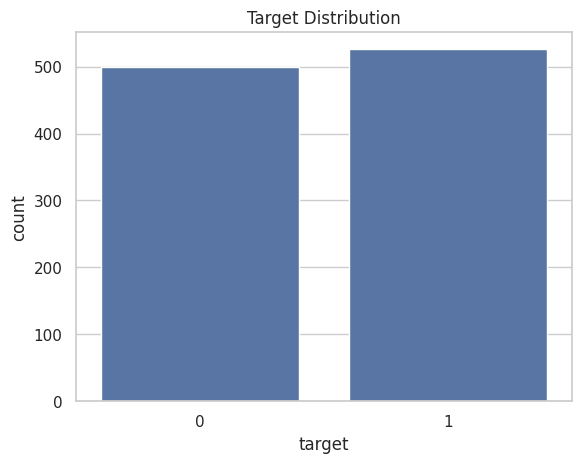

In [30]:
sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()

Heatmap

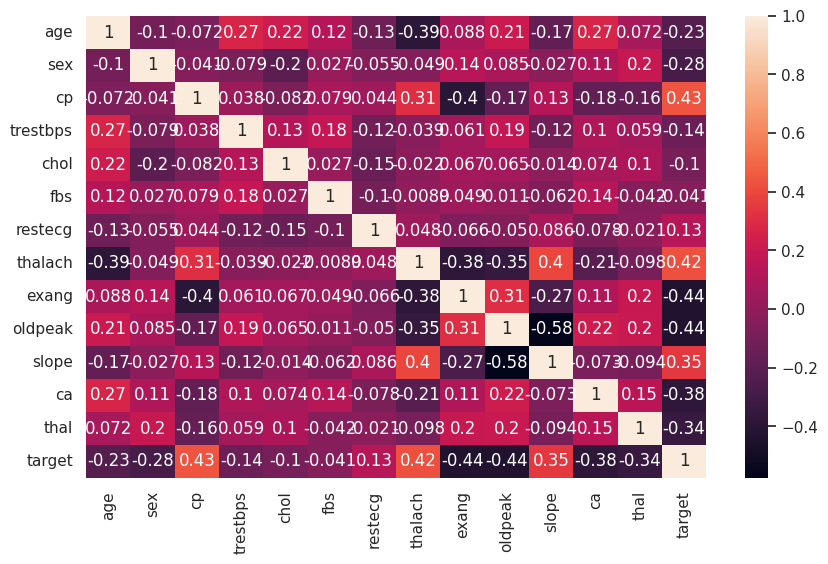

In [31]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

Histograms

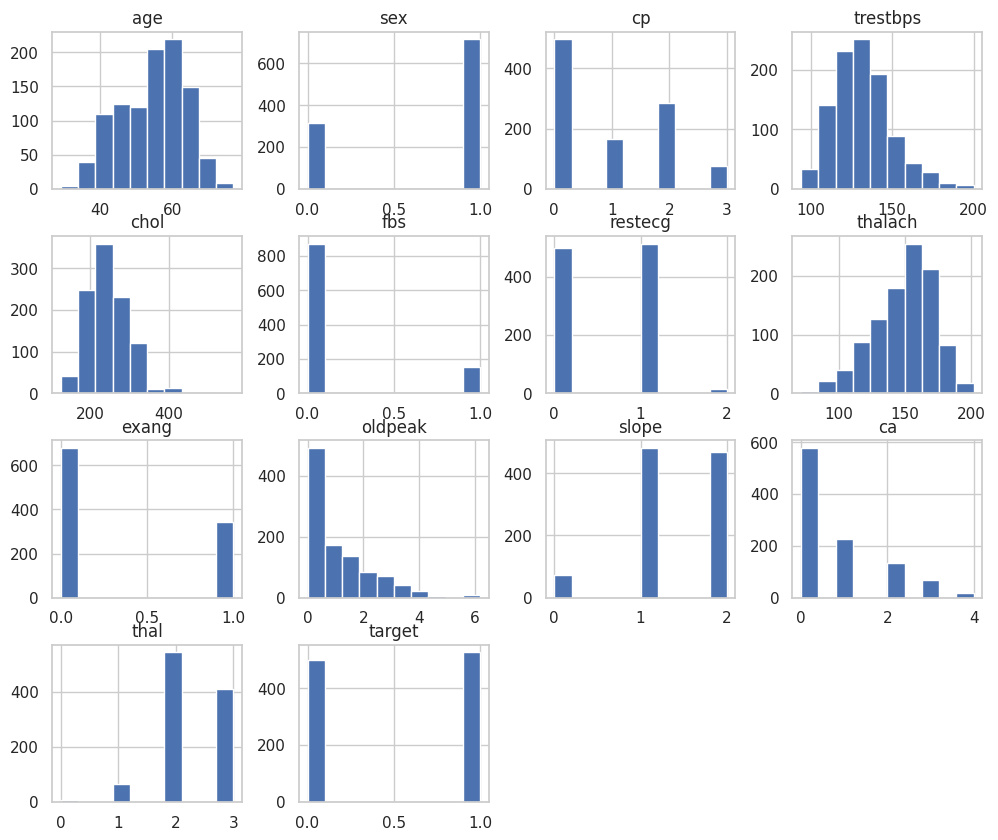

In [32]:
df.hist(figsize=(12,10))
plt.show()

# STEP 6: Feature Selection

In [33]:
X = df.drop('target', axis=1)
y = df['target']

#  STEP 7: Train Test Split

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# STEP 8: Model (Decision Tree)

In [35]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(criterion='gini', max_depth=4)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4)

In [43]:
model_gini = DecisionTreeClassifier(criterion='gini', max_depth=4)
model_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=4)

model_gini.fit(X_train, y_train)
model_entropy.fit(X_train, y_train)

print("Gini Accuracy:", model_gini.score(X_test, y_test))
print("Entropy Accuracy:", model_entropy.score(X_test, y_test))

Gini Accuracy: 0.8
Entropy Accuracy: 0.7902439024390244


# STEP 9: Prediction

In [36]:
y_pred = model.predict(X_test)

# STEP 10: Evaluation

In [37]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8
[[71 31]
 [10 93]]
              precision    recall  f1-score   support

           0       0.88      0.70      0.78       102
           1       0.75      0.90      0.82       103

    accuracy                           0.80       205
   macro avg       0.81      0.80      0.80       205
weighted avg       0.81      0.80      0.80       205



# STEP 11: GRAPHS

Confusion Matrix

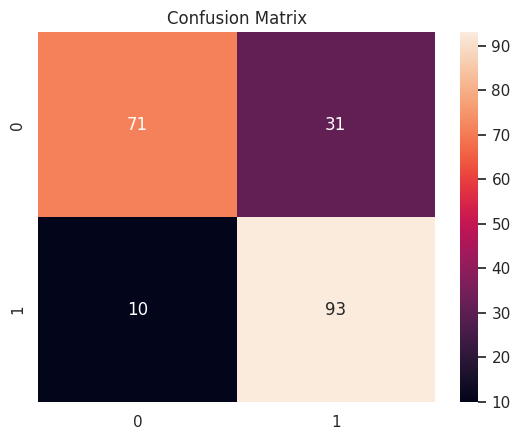

In [38]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

Actual vs Predicted

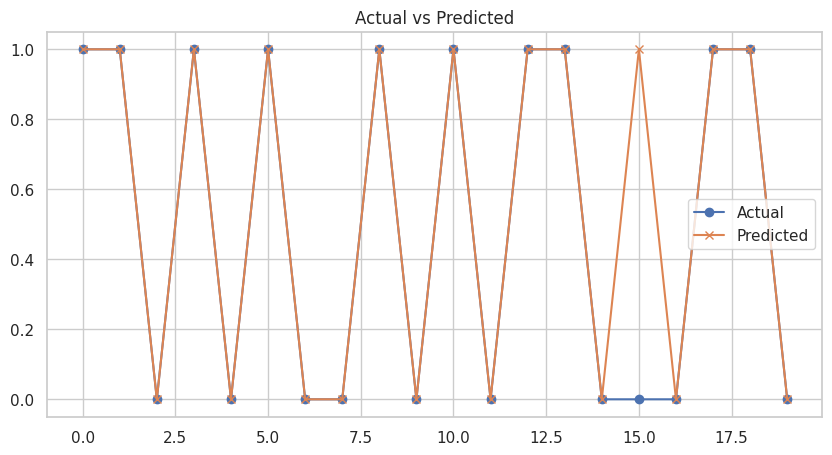

In [39]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:20], label='Actual', marker='o')
plt.plot(y_pred[:20], label='Predicted', marker='x')
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

# STEP 12: FEATURE IMPORTANCE

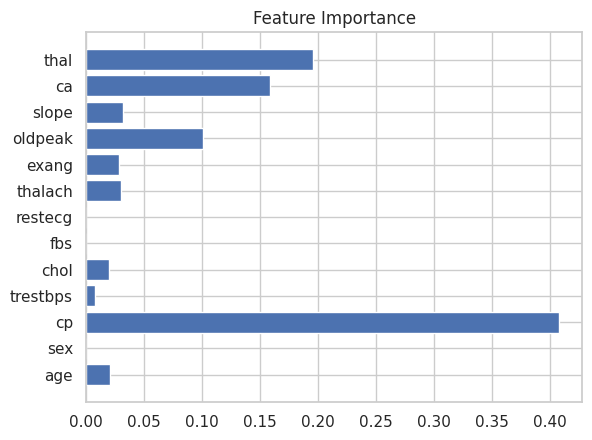

In [40]:
importance = model.feature_importances_

plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.show()

# STEP 13: TREE VISUALIZATION

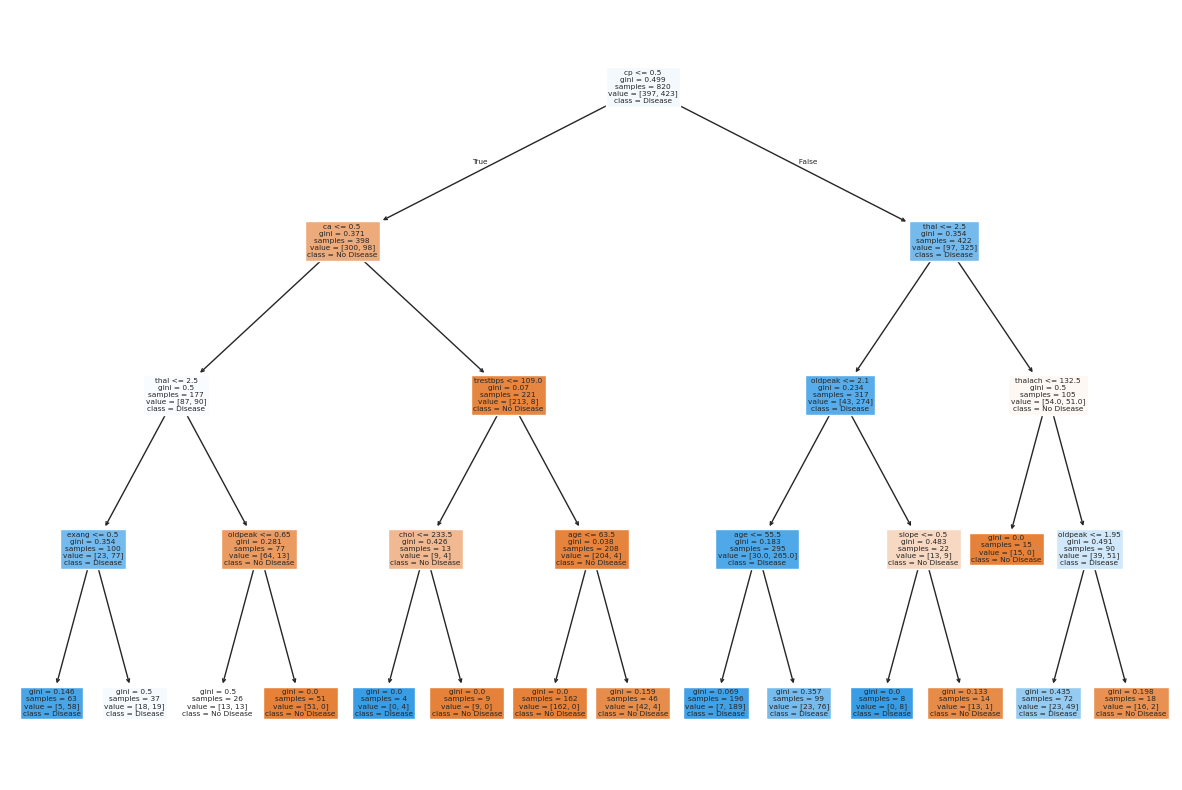

In [41]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15,10))
plot_tree(model, feature_names=X.columns, class_names=['No Disease','Disease'], filled=True)
plt.show()

# STEP 14: CROSS VALIDATION

In [42]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print("Cross Validation Score:", scores.mean())

Cross Validation Score: 0.8341463414634147


# Conclusion

The Decision Tree model performed well with good accuracy. 
Gini and Entropy were compared, and the best performing model was selected. 
Feature importance helped identify key factors affecting predictions.